# Notebook 03 – Predict 2025-26 NBA All-Stars

**What this notebook does:**
1. Loads the trained pipeline from `models/pipeline.joblib`.
2. Fetches 2025-26 player game logs from the NBA API (Oct 1, 2025 – Feb 1, 2026).
3. Builds features using the **same** preprocessing as training.
4. Runs `pipeline.predict_proba` and ranks players.
5. Outputs the top 24 predicted All-Stars with probabilities.

**Prerequisites**: run notebook 01 and notebook 02 first.


In [60]:
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))


In [61]:
# ── Configuration ────────────────────────────────────────────────────────
TARGET_SEASON = "2025-26"   # prediction target
CUTOFF_DATE   = "2026-02-01"

DATA_DIR      = REPO_ROOT / "data"
CACHE_DIR     = DATA_DIR / "cache"
MODELS_DIR    = REPO_ROOT / "models"
PIPELINE_PATH = MODELS_DIR / "pipeline.joblib"
META_PATH     = MODELS_DIR / "pipeline_meta.json"

CACHE_DIR.mkdir(parents=True, exist_ok=True)


In [62]:
import json
import joblib
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Load pipeline
pipeline = joblib.load(PIPELINE_PATH)
print("Pipeline loaded.")

# Load metadata (feature schema)
with open(META_PATH) as f:
    meta = json.load(f)

FEATURE_COLS = meta["feature_cols"]
print(f"Expected feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS[:5]} …")


Pipeline loaded.
Expected feature columns (57): ['PLAYER_AGE', 'GP', 'GS', 'MIN', 'FGM'] …


In [63]:
# 1) 커널에서 모듈 강제 리로드
import importlib
import src.feature_engineering as fe
importlib.reload(fe)

# 2) 리로드된 함수로 호출
feats_2526 = fe.build_features_for_season(
    season=TARGET_SEASON,
    cache_dir=CACHE_DIR,
    end_date=CUTOFF_DATE,
)
print(len(feats_2526))

520


## Build 2025-26 Features (Oct 1, 2025 → Feb 1, 2026)

In [64]:
## Build 2025-26 Features (Oct 1, 2025 → Feb 1, 2026)

from src.feature_engineering import build_features_for_season

feats_2526 = build_features_for_season(
    season=TARGET_SEASON,
    cache_dir=CACHE_DIR,
    end_date=CUTOFF_DATE,   
)

print(f"Players with data: {len(feats_2526)}")
feats_2526.head(3)

Players with data: 520


,PLAYER_ID,MIN,FGM,FGA,FG3M,FG3A,FTM,FTA,OREB,DREB,...,PF,PTS,GP,PLAYER_NAME,team,FG_PCT,FG3_PCT,FT_PCT,year,PLAYER_AGE
0,2544,1027,253,501,47,143,126,171,22,157,...,45,679,31,LeBron James,LAL,0.504990,0.328671,0.736842,2025,NaN
1,101108,228,18,56,10,30,1,2,6,22,...,23,47,16,Chris Paul,LAC,0.321429,0.333333,0.500000,2025,NaN
2,200768,44,2,8,2,8,0,0,0,3,...,3,6,6,Kyle Lowry,PHI,0.250000,0.250000,NaN,2025,NaN


In [83]:
# Load scaler
SCALER_FILE = DATA_DIR / "scaler.pkl"
scaler = joblib.load(SCALER_FILE)
print("Scaler loaded.")

# One-Hot Encode team (02와 동일하게)
feats_2526_encoded = pd.get_dummies(feats_2526, columns=['team'], prefix='team')

# 동일한 feature columns 선택
drop_cols = {'PLAYER_ID', 'first', 'last', 'year'}
feature_cols_raw = [c for c in feats_2526_encoded.columns if c not in drop_cols]
X_raw = feats_2526_encoded[feature_cols_raw]

# NaN을 평균값으로 채우기 (scaling 전에!)
X_raw = X_raw.fillna(X_raw.mean())
print(f"After fillna with mean: {X_raw.isna().sum().sum()} NaN values")

# 스케일러가 학습한 컬럼 순서로 reindex (누락은 0으로 채우기)
X_raw_aligned = X_raw.reindex(columns=FEATURE_COLS, fill_value=0)

print(f"Original columns: {X_raw.shape[1]}")
print(f"Expected columns: {len(FEATURE_COLS)}")
print(f"Missing: {[c for c in FEATURE_COLS if c not in X_raw.columns]}")

# Scaling 적용
X_pred = scaler.transform(X_raw_aligned)
X_pred = pd.DataFrame(X_pred, columns=FEATURE_COLS)

# Keep player metadata
player_meta = feats_2526[["PLAYER_ID", "PLAYER_NAME", "team", "GP"]].copy()
print(f"Feature matrix shape: {X_pred.shape}")
print(f"Final NaN check: {X_pred.isna().sum().sum()}")
print(f"Columns match: {len(X_pred.columns)} features")

Scaler loaded.


TypeError: Could not convert ["LeBron JamesChris PaulKyle LowryKevin DurantAl HorfordMike ConleyJeff GreenRussell WestbrookKevin LoveEric GordonBrook LopezNicolas BatumDeAndre JordanJames HardenStephen CurryDeMar DeRozanJrue HolidayGarrett TemplePaul GeorgeJonas ValančiūnasBismack BiyomboKlay ThompsonKawhi LeonardNikola VučevićTobias HarrisJimmy Butler IIIAnthony DavisBradley BealAndre DrummondHarrison BarnesDraymond GreenKhris MiddletonCJ McCollumDennis SchröderKelly OlynykKentavious Caldwell-PopeMason PlumleeRudy GobertSteven AdamsTim Hardaway Jr.Giannis AntetokounmpoSeth CurryThanasis AntetokounmpoZach LaVineJordan ClarksonGary HarrisJerami GrantDoug McDermottAaron GordonMarcus SmartKyle AndersonDwight PowellJulius RandleAndrew WigginsJoel EmbiidDario SaricClint CapelaBogdan BogdanovićJusuf NurkićNikola JokićKristaps PorziņģisJoe InglesT.J. McConnellTyus JonesD'Angelo RussellKarl-Anthony TownsKelly Oubre Jr.Devin BookerMyles TurnerBobby PortisKevon LooneyNorman PowellPat Connaughton

## Predict and Rank

In [78]:
## Predict and Rank

probas = pipeline.predict_proba(X_pred)[:, 1]
player_meta = player_meta.copy()
player_meta["ALLSTAR_PROB"] = probas

# Rank players by predicted probability
player_meta = player_meta.sort_values("ALLSTAR_PROB", ascending=False).reset_index(drop=True)
player_meta.index += 1   # 1-based rank

print(f"Top 24 predicted All-Stars for the {TARGET_SEASON} season")
print(f"(stats aggregated through {CUTOFF_DATE})\n")
top24 = player_meta.head(24)
print(top24[["PLAYER_NAME", "team", "GP", "ALLSTAR_PROB"]].to_string())

Top 24 predicted All-Stars for the 2025-26 season
(stats aggregated through 2026-02-01)

                PLAYER_NAME team  GP  ALLSTAR_PROB
1   Shai Gilgeous-Alexander  OKC  48      0.978049
2               Luka Dončić  LAL  40      0.976186
3              Tyrese Maxey  PHI  46      0.969692
4              Jaylen Brown  BOS  45      0.906229
5           Cade Cunningham  DET  42      0.883190
6             Jalen Johnson  ATL  46      0.844630
7          Donovan Mitchell  CLE  47      0.843455
8              Nikola Jokić  DEN  34      0.788663
9               Deni Avdija  POR  44      0.738171
10            Jalen Brunson  NYK  44      0.728700
11            Pascal Siakam  IND  47      0.697567
12        Victor Wembanyama  SAS  35      0.697178
13             Kevin Durant  HOU  45      0.660994
14    Giannis Antetokounmpo  MIL  30      0.647040
15             James Harden  LAC  44      0.517628
16           Scottie Barnes  TOR  50      0.475771
17             Jamal Murray  DEN  45      0.

In [80]:
import numpy as np
import pandas as pd

print("=== 진단 ===")
print(f"X_raw shape: {X_raw.shape}")
print(f"X_raw NaN count: {X_raw.isna().sum().sum()}")
print(f"X_raw_aligned shape: {X_raw_aligned.shape}")
print(f"X_raw_aligned NaN count: {X_raw_aligned.isna().sum().sum()}")
print(f"X_pred shape: {X_pred.shape}")
print(f"X_pred NaN count: {X_pred.isna().sum().sum()}")

if X_pred.isna().sum().sum() > 0:
    nan_cols = X_pred.columns[X_pred.isna().any()].tolist()
    print(f"NaN in columns: {nan_cols[:10]}")

=== 진단 ===
X_raw shape: (520, 52)
X_raw NaN count: 593
X_raw_aligned shape: (520, 57)
X_raw_aligned NaN count: 593
X_pred shape: (520, 57)
X_pred NaN count: 0


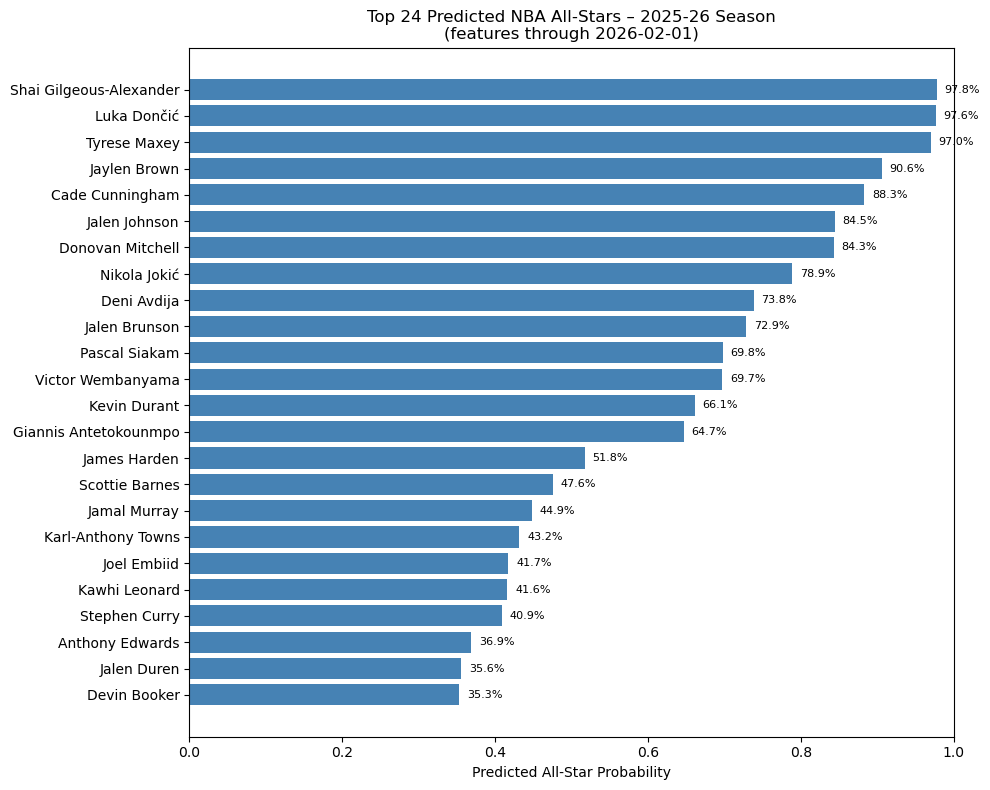

Plot saved to data/top24_2025_26.png


In [81]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top24["PLAYER_NAME"].iloc[::-1], top24["ALLSTAR_PROB"].iloc[::-1], color="steelblue")
ax.set_xlabel("Predicted All-Star Probability")
ax.set_title(f"Top 24 Predicted NBA All-Stars – {TARGET_SEASON} Season\n(features through {CUTOFF_DATE})")
ax.set_xlim(0, 1)
for i, (name, prob) in enumerate(zip(top24["PLAYER_NAME"].iloc[::-1], top24["ALLSTAR_PROB"].iloc[::-1])):
    ax.text(prob + 0.01, i, f"{prob:.1%}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(DATA_DIR / "top24_2025_26.png", dpi=150)
plt.show()
print("Plot saved to data/top24_2025_26.png")


In [ ]:
# Save full ranking to CSV
output_path = DATA_DIR / "predictions_2025_26.csv"
player_meta.to_csv(output_path)
print(f"Full ranking saved to {output_path}")
